## SAM2 — Image Segmentation with Point / Box Prompts

In [6]:
import torch

print(f"PyTorch 버전: {torch.__version__}")
print(f"CUDA 사용 가능: {torch.cuda.is_available()}")
print(f"사용 가능한 GPU 수: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    total = torch.cuda.get_device_properties(i).total_memory / 1024**3
    reserved = torch.cuda.memory_reserved(i) / 1024**3
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)}  |  전체: {total:.1f}GB  |  예약: {reserved:.1f}GB")

DEVICE = "cuda:2"
print(f"\n사용 디바이스: {DEVICE}")

PyTorch 버전: 2.9.1+cu128
CUDA 사용 가능: True
사용 가능한 GPU 수: 4
  GPU 0: NVIDIA GeForce RTX 5090  |  전체: 31.4GB  |  예약: 0.2GB
  GPU 1: NVIDIA GeForce RTX 5090  |  전체: 31.4GB  |  예약: 0.0GB
  GPU 2: NVIDIA GeForce RTX 5090  |  전체: 31.4GB  |  예약: 1.6GB
  GPU 3: NVIDIA GeForce RTX 5090  |  전체: 31.4GB  |  예약: 0.0GB

사용 디바이스: cuda:2


In [7]:
from sam2.sam2_image_predictor import SAM2ImagePredictor
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator

MODEL_ID = "facebook/sam2.1-hiera-large"

predictor = SAM2ImagePredictor.from_pretrained(MODEL_ID, device=DEVICE)
print("SAM2ImagePredictor 로드 완료")

SAM2ImagePredictor 로드 완료


발견된 이미지 파일: ['desk.jpeg', 'xai506_example_image.jpg']

[desk.jpeg]
원본 크기: 4000 x 3000
리사이즈 후: 1024 x 768

[xai506_example_image.jpg]
원본 크기: 4032 x 3024
리사이즈 후: 1024 x 768


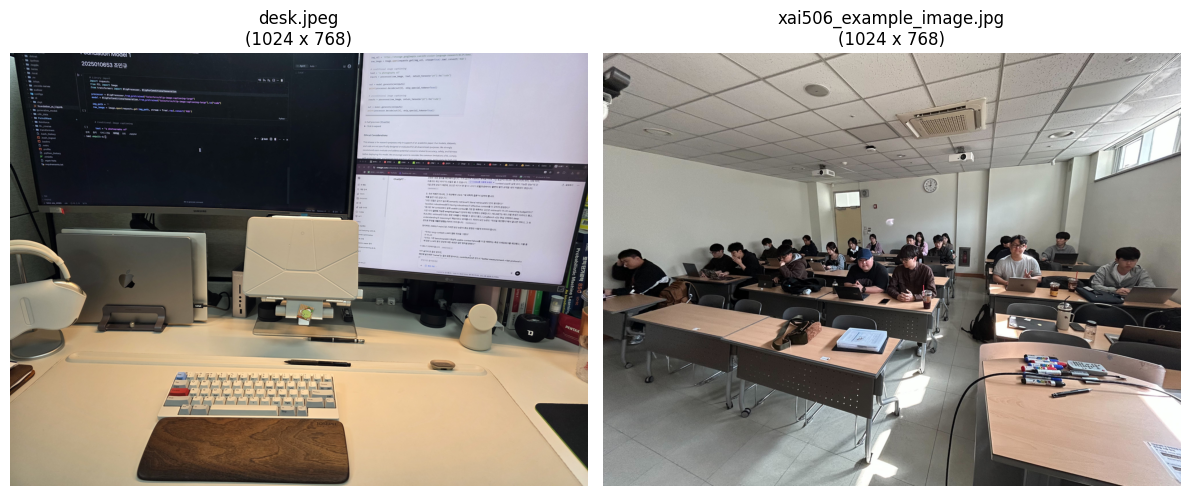

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

IMG_DIR  = "/img" #이미지 저장 위치
MAX_SIZE = 1024

def load_and_resize(img_path: str) -> Image.Image:
    image = Image.open(img_path).convert("RGB")
    w, h = image.size
    print(f"원본 크기: {w} x {h}")
    if w > MAX_SIZE or h > MAX_SIZE:
        ratio = min(MAX_SIZE / w, MAX_SIZE / h)
        new_w, new_h = int(w * ratio), int(h * ratio)
        image = image.resize((new_w, new_h), Image.LANCZOS)
        print(f"리사이즈 후: {new_w} x {new_h}")
    else:
        print("리사이즈 불필요")
    return image

# img 디렉토리 내 이미지 파일 목록
img_files = sorted([
    f for f in os.listdir(IMG_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
])
print(f"발견된 이미지 파일: {img_files}")

# 이미지 로드 및 미리보기
images = {}
fig, axes = plt.subplots(1, len(img_files), figsize=(6 * len(img_files), 5))
if len(img_files) == 1:
    axes = [axes]

for ax, fname in zip(axes, img_files):
    path = os.path.join(IMG_DIR, fname)
    print(f"\n[{fname}]")
    img = load_and_resize(path)
    images[fname] = img
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"{fname}\n({img.width} x {img.height})")

plt.tight_layout()
plt.show()

In [9]:
def _overlay_mask(ax, mask: np.ndarray, color: list, alpha: float = 0.45) -> None:
    """단일 마스크를 ax 위에 색상 오버레이로 그립니다."""
    h, w = mask.shape
    overlay = np.zeros((h, w, 4), dtype=np.float32)
    overlay[mask > 0.5] = color + [alpha]
    ax.imshow(overlay)


def segment_with_points(
    image: Image.Image,
    point_coords: list,
    point_labels: list,
    multimask_output: bool = True,
) -> tuple:
    """
    포인트 프롬프트로 세그멘테이션을 수행합니다.

    Args:
        image          : PIL Image
        point_coords   : [[x, y], ...] 형태의 포인트 좌표 목록
        point_labels   : [1 또는 0, ...] (1=전경, 0=배경)
        multimask_output: True면 3개 마스크 후보 반환

    Returns:
        masks (N, H, W), scores (N,), logits (N, H, W)
    """
    with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
        predictor.set_image(np.array(image))
        masks, scores, logits = predictor.predict(
            point_coords=np.array(point_coords),
            point_labels=np.array(point_labels),
            multimask_output=multimask_output,
        )
    order = np.argsort(scores)[::-1]
    return masks[order], scores[order], logits[order]


def segment_with_box(
    image: Image.Image,
    box: list,
) -> tuple:
    """
    박스 프롬프트로 세그멘테이션을 수행합니다.

    Args:
        image: PIL Image
        box  : [x0, y0, x1, y1] 픽셀 좌표

    Returns:
        masks (N, H, W), scores (N,), logits (N, H, W)
    """
    with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
        predictor.set_image(np.array(image))
        masks, scores, logits = predictor.predict(
            box=np.array(box),
            multimask_output=False,
        )
    return masks, scores, logits


def visualize_masks(
    image: Image.Image,
    masks: np.ndarray,
    scores: np.ndarray,
    point_coords: list = None,
    point_labels: list = None,
    box: list = None,
    title: str = "",
) -> None:
    """마스크 결과를 이미지 위에 오버레이로 시각화합니다."""
    cmap   = plt.colormaps.get_cmap("tab10")
    n      = len(masks)
    ncols  = min(n, 3)
    fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 5))
    if ncols == 1:
        axes = [axes]

    for i, (ax, mask, score) in enumerate(zip(axes, masks, scores)):
        color = list(cmap(i % 10))[:3]
        ax.imshow(image)
        _overlay_mask(ax, mask, color)

        # 포인트 표시
        if point_coords is not None:
            for (x, y), lbl in zip(point_coords, point_labels):
                marker_color = "lime" if lbl == 1 else "red"
                ax.scatter(x, y, s=120, c=marker_color, edgecolors="white", linewidths=1.5, zorder=5)

        # 박스 표시
        if box is not None:
            x0, y0, x1, y1 = box
            rect = patches.Rectangle(
                (x0, y0), x1 - x0, y1 - y0,
                linewidth=2, edgecolor="yellow", facecolor="none",
            )
            ax.add_patch(rect)

        ax.set_title(f"Mask {i+1}  score={score:.3f}")
        ax.axis("off")

    fig.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.show()

### 단일 이미지 — 포인트 프롬프트

이미지  : desk.jpeg  (1024 x 768)
포인트  : [[300, 200]]
레이블  : [1]  (1=전경, 0=배경)

  Mask 1: score=0.973
  Mask 2: score=0.848
  Mask 3: score=0.773


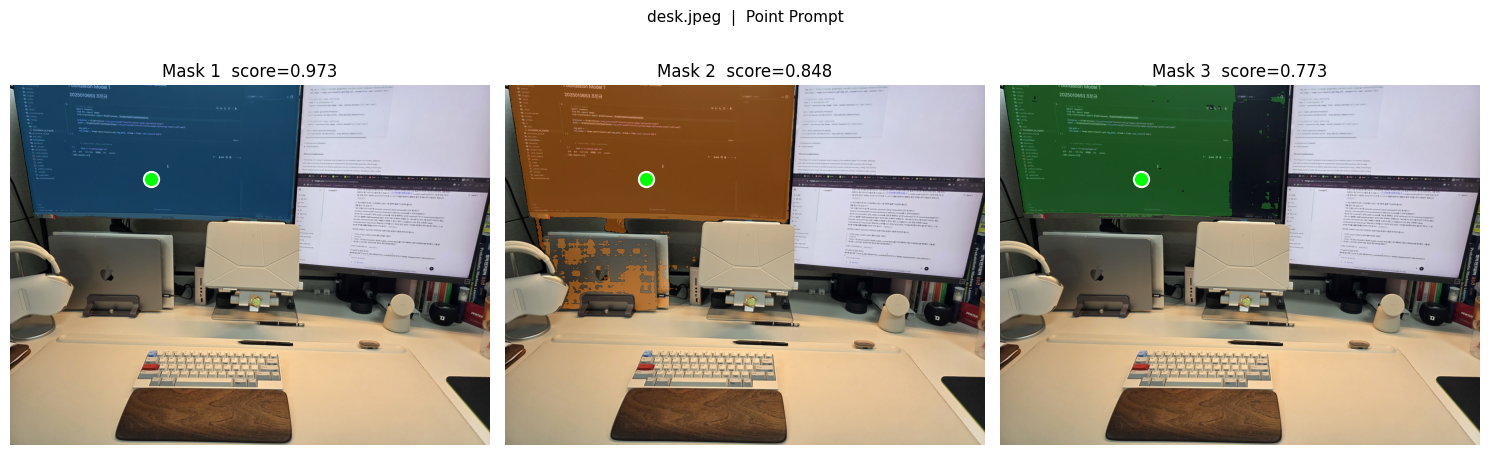

In [10]:
TARGET_IMAGE  = "desk.jpeg"
# TARGET_IMAGE  = "xai506_example_image.jpg"

# 포인트 좌표 [x, y] 및 레이블 (1=전경, 0=배경)
POINT_COORDS  = [[300, 200]]
POINT_LABELS  = [1]

selected_image = images[TARGET_IMAGE]
print(f"이미지  : {TARGET_IMAGE}  ({selected_image.width} x {selected_image.height})")
print(f"포인트  : {POINT_COORDS}")
print(f"레이블  : {POINT_LABELS}  (1=전경, 0=배경)\n")

masks, scores, _ = segment_with_points(selected_image, POINT_COORDS, POINT_LABELS)

for i, score in enumerate(scores):
    print(f"  Mask {i+1}: score={score:.3f}")

visualize_masks(
    selected_image, masks, scores,
    point_coords=POINT_COORDS, point_labels=POINT_LABELS,
    title=f"{TARGET_IMAGE}  |  Point Prompt",
)

### 단일 이미지 — 박스 프롬프트

이미지 : desk.jpeg  (1024 x 768)
박스   : [100, 80, 500, 400]  [x0, y0, x1, y1]

  Mask 1: score=0.535


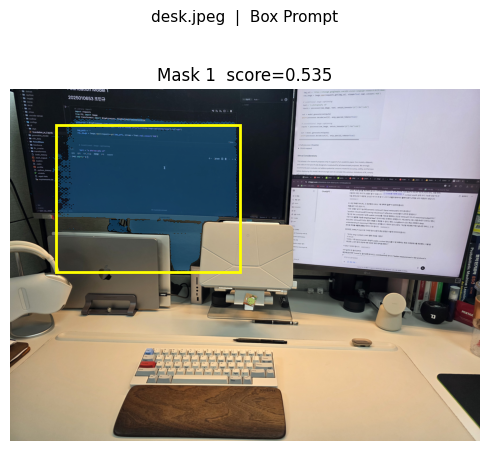

In [11]:
TARGET_IMAGE = "desk.jpeg"
# TARGET_IMAGE  = "xai506_example_iamge.jpg"

# 박스 좌표 [x0, y0, x1, y1]
BOX = [100, 80, 500, 400]

selected_image = images[TARGET_IMAGE]
print(f"이미지 : {TARGET_IMAGE}  ({selected_image.width} x {selected_image.height})")
print(f"박스   : {BOX}  [x0, y0, x1, y1]\n")

masks, scores, _ = segment_with_box(selected_image, BOX)

for i, score in enumerate(scores):
    print(f"  Mask {i+1}: score={score:.3f}")

visualize_masks(
    selected_image, masks, scores,
    box=BOX,
    title=f"{TARGET_IMAGE}  |  Box Prompt",
)

### 전체 이미지 — 자동 마스크 생성 (Automatic Mask Generator)

이미지: desk.jpeg  (1024 x 768)
검출된 마스크 수: 64


/tmp/ipykernel_3829215/4061300999.py:22: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3829215/4061300999.py:22: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3829215/4061300999.py:22: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3829215/4061300999.py:22: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3829215/4061300999.py:22: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3829215/4061300999.py:22: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3829215/4061300999.py:22: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu S

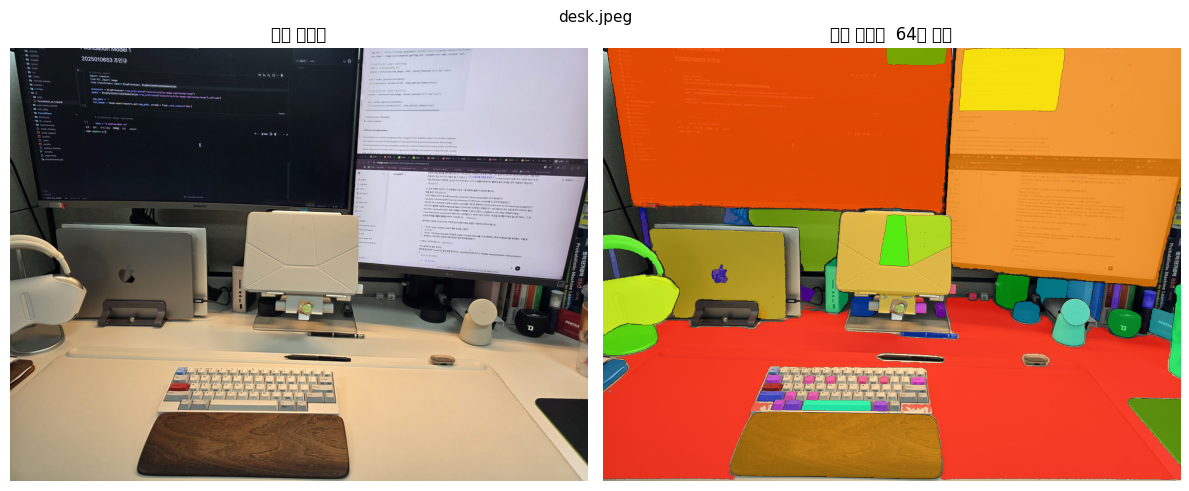


이미지: xai506_example_image.jpg  (1024 x 768)
검출된 마스크 수: 120


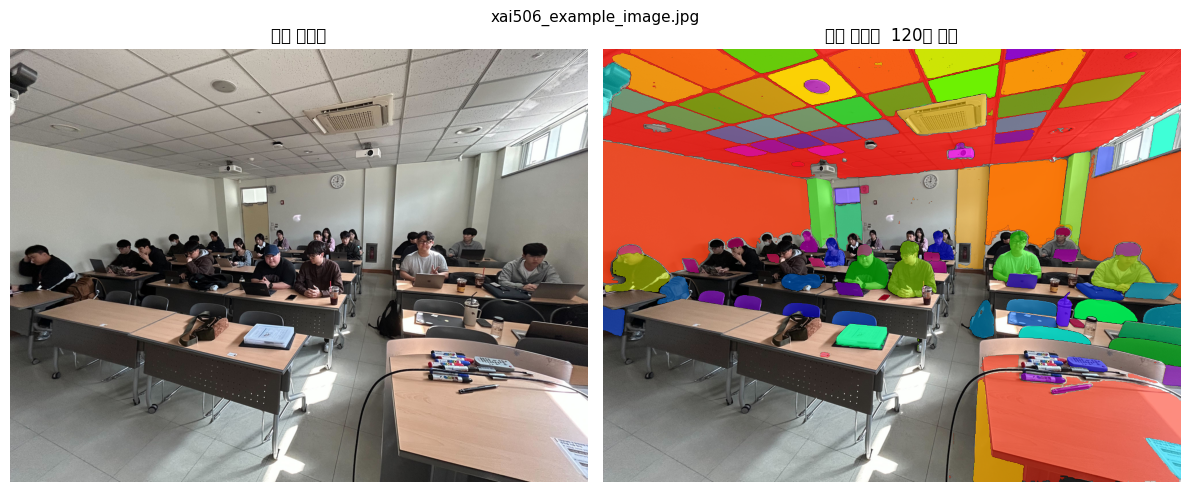

In [12]:
mask_generator = SAM2AutomaticMaskGenerator.from_pretrained(MODEL_ID, device=DEVICE)

def visualize_auto_masks(image: Image.Image, anns: list, title: str = "") -> None:
    """자동 생성된 마스크 전체를 색상별로 오버레이합니다."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].imshow(image)
    axes[0].set_title("원본 이미지")
    axes[0].axis("off")

    axes[1].imshow(image)
    cmap = plt.colormaps.get_cmap("hsv").resampled(len(anns))
    for i, ann in enumerate(sorted(anns, key=lambda x: x["area"], reverse=True)):
        mask  = ann["segmentation"]
        color = list(cmap(i))[:3]
        _overlay_mask(axes[1], mask, color, alpha=0.5)

    axes[1].set_title(f"자동 마스크  {len(anns)}개 검출")
    axes[1].axis("off")

    fig.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.show()

for fname, img in images.items():
    print("=" * 60)
    print(f"이미지: {fname}  ({img.width} x {img.height})")
    with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
        anns = mask_generator.generate(np.array(img))
    print(f"검출된 마스크 수: {len(anns)}")
    visualize_auto_masks(img, anns, title=fname)
    print()

### 이미지 선택 후 포인트 / 박스 프롬프트 반복 입력

사용 가능한 이미지:
  [0] desk.jpeg
  [1] xai506_example_image.jpg

선택된 이미지: xai506_example_image.jpg  (1024 x 768)


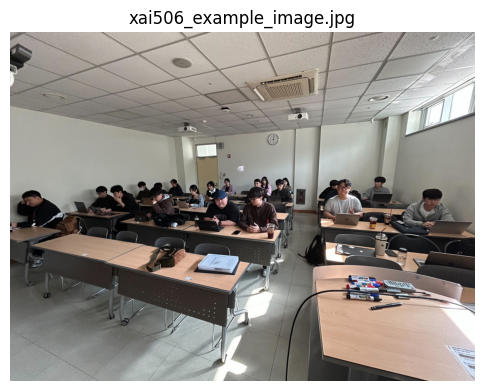


프롬프트 형식:
  포인트: p x,y [x,y ...]   예) p 300,200 400,300
          fg/bg 레이블은 공백 뒤에 추가  예) p 300,200:1 100,50:0
  박스  : b x0,y0,x1,y1    예) b 100,80,500,400
  종료  : q

  ※ 'p' 또는 'b'로 시작하는 프롬프트를 입력해주세요.
  ※ 입력 형식 오류: not enough values to unpack (expected 2, got 1)


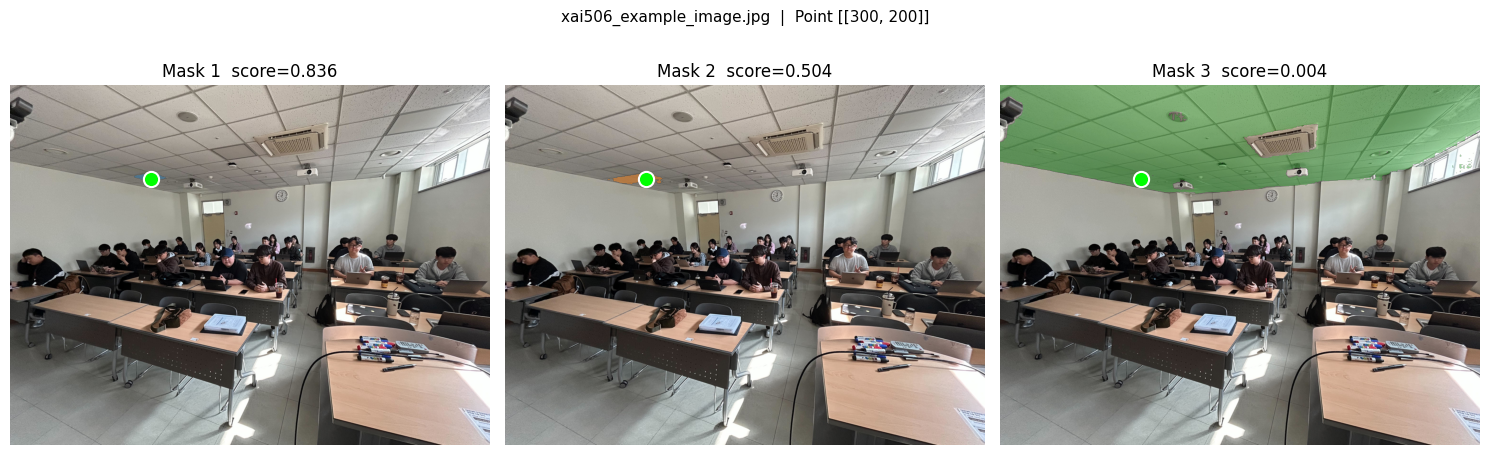

세그멘테이션을 종료합니다.


In [13]:
# ── 이미지 선택 ───────────────────────────────────────────────
print("사용 가능한 이미지:")
for idx, fname in enumerate(img_files):
    print(f"  [{idx}] {fname}")

while True:
    sel = input("\n이미지 번호 또는 파일명 입력: ").strip()
    if sel.isdigit() and int(sel) < len(img_files):
        chat_fname = img_files[int(sel)]
    elif sel in images:
        chat_fname = sel
    else:
        print(f"  ※ '{sel}'을(를) 찾을 수 없습니다. 다시 입력해주세요.")
        continue
    break

chat_img = images[chat_fname]
print(f"\n선택된 이미지: {chat_fname}  ({chat_img.width} x {chat_img.height})")
plt.figure(figsize=(6, 5))
plt.imshow(chat_img)
plt.axis("off")
plt.title(chat_fname)
plt.show()

# ── 프롬프트 반복 입력 ────────────────────────────────────────
print("\n프롬프트 형식:")
print("  포인트: p x,y [x,y ...]   예) p 300,200 400,300")
print("          fg/bg 레이블은 공백 뒤에 추가  예) p 300,200:1 100,50:0")
print("  박스  : b x0,y0,x1,y1    예) b 100,80,500,400")
print("  종료  : q\n")

while True:
    raw = input("프롬프트: ").strip()
    if raw.lower() in ("q", "quit", "exit", ""):
        print("세그멘테이션을 종료합니다.")
        break

    mode = raw[0].lower()
    args = raw[2:].strip()

    try:
        if mode == "p":
            # 파싱: "x,y[:label] ..."
            coords, labels = [], []
            for token in args.split():
                if ":" in token:
                    xy, lbl = token.split(":")
                    labels.append(int(lbl))
                else:
                    xy  = token
                    labels.append(1)   # 기본값: 전경
                x, y = map(int, xy.split(","))
                coords.append([x, y])

            masks, scores, _ = segment_with_points(chat_img, coords, labels)
            visualize_masks(
                chat_img, masks, scores,
                point_coords=coords, point_labels=labels,
                title=f"{chat_fname}  |  Point {coords}",
            )

        elif mode == "b":
            x0, y0, x1, y1 = map(int, args.split(","))
            box = [x0, y0, x1, y1]
            masks, scores, _ = segment_with_box(chat_img, box)
            visualize_masks(
                chat_img, masks, scores,
                box=box,
                title=f"{chat_fname}  |  Box {box}",
            )
        else:
            print("  ※ 'p' 또는 'b'로 시작하는 프롬프트를 입력해주세요.")

    except Exception as e:
        print(f"  ※ 입력 형식 오류: {e}")